<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie plotly express
import plotly.express as px

In [3]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

# https://stackoverflow.com/questions/49188960/how-to-show-all-columns-names-on-a-large-pandas-dataframe
# pd.set_option('display.max_columns', None)

# On peut aussi utiliser la fonction "columns.tolist()"

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

c:\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [6]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()

Le tableau comporte 6 colonne(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [7]:
#Afficher les 5 premières lignes de la table
df_erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [8]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
duplicates = df_erp[df_erp.duplicated(subset='product_id')]
duplicates


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


In [9]:
#on peut vérifier si on a bien 825 avleurs uniques
nb_id = df_erp['product_id'].unique()
len(nb_id)

825

In [10]:
#Afficher les valeurs distinctes de la colonne stock_status
val_stock_status = df_erp['stock_status'].unique()
print(val_stock_status)

['instock' 'outofstock']


In [11]:
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
df_out_of_stock = df_erp.loc[df_erp['stock_status'] == 'outofstock']
df_out_of_stock

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
2,3850,1,20.8,0,outofstock,10.64
4,4039,1,46.0,3,outofstock,23.77
8,4043,1,60.0,0,outofstock,29.45
11,4047,1,18.3,0,outofstock,9.93
15,4051,1,7.7,0,outofstock,4.14
...,...,...,...,...,...,...
723,6301,1,40.5,0,outofstock,20.51
726,6327,0,28.5,0,outofstock,14.43
752,6632,1,52.7,0,outofstock,26.41
774,6900,0,30.0,0,outofstock,16.28


In [12]:
# Je suppose product_id et stock_quantity

In [13]:
#Création d'une colonne "stock_status_2"
df_erp['stock_status_2'] = 'instock'
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = 'instock'

df_erp.loc[df_erp['stock_quantity'] <= 0, "stock_status_2"] = "outofstock"
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [14]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]
#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [15]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 825 qui correspond au nombre de lignes dans ce dataset
sum(df_erp["stock_status"] == df_erp["stock_status_2"])


823

In [16]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
# https://bitbucket.org/hrojas/learn-pandas/src/master/
df_erp.loc[df_erp["stock_status"] != df_erp["stock_status_2"]]
##Lesson 3


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [17]:
#Corriger la ou les données incohérentes
df_erp.loc[df_erp['stock_quantity'] < 1, 'stock_status'] = 'outofstock'
df_erp.loc[df_erp['stock_quantity'] >= 1, 'stock_status'] = 'instock'

In [18]:
df_erp.loc[df_erp["stock_status"] != df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


In [19]:
#Vérification en utilisant le même code que plus haut pour afficher les problèmes
sum(df_erp["stock_status"] == df_erp["stock_status_2"])


825

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [20]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['price'].isnull().sum())) #Saisir l'instruction manquante dans la fonction format

Nombres d'articles avec un prix non renseigné: 0


In [21]:
#Afficher le prix minimum de la colonne "price"
print("Prix minimum sur un article: {} €".format(df_erp['price'].min()))

Prix minimum sur un article: -20.0 €


In [22]:
#Afficher le prix maximum de la colonne "price"
print("Prix maximum sur un article: {} €".format(df_erp['price'].max()))

Prix maximum sur un article: 225.0 €


In [112]:
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("liste des prix inférieurs à 0 :  {}".format(df_erp.loc[df_erp['price'] < 0, 'price'].unique()))

liste des prix inférieurs à 0 :  []


In [24]:
#Je pense que le mieux est de les supprimer
df_erp = df_erp[~(df_erp['price'] < 0)]

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [25]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
print("Nombres d'articles avec un stock non renseigné: {}".format(df_erp['stock_quantity'].isnull().sum()))

Nombres d'articles avec un stock non renseigné: 0


In [26]:
#Afficher la quantité minimum de la colonne "stock_quantity"
print("Quantité minimum sur un article: {}.".format(df_erp['stock_quantity'].min()))

Quantité minimum sur un article: -10.


In [27]:
#Afficher la quantité maximum de la colonne "stock_quantity"
print("Quantité maximum sur un article: {}.".format(df_erp['stock_quantity'].max()))

Quantité maximum sur un article: 145.


In [28]:
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("liste des prix inférieurs à 0 :  {}".format(df_erp.loc[df_erp['stock_quantity'] < 0, 'stock_quantity'].unique()))

liste des prix inférieurs à 0 :  [-10  -1]


In [29]:
# les remettre à 0 me semble etre la bonne approche
df_erp.loc[df_erp['stock_quantity'] < 0, 'stock_quantity'] = 0

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [30]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp['onsale_web'].unique()

array([1, 0])

In [113]:
df_erp['onsale_web'].describe()
# C'est une colonne avec 1 ou 0 qui dit si le produit est en offre sur le site (1 = True ; 0 = False)

count    822.000000
mean       0.871046
std        0.335353
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: onsale_web, dtype: float64

In [32]:
#Quelles sont les colonnes à conserver selon vous?
df_erp.columns.tolist()

['product_id',
 'onsale_web',
 'price',
 'stock_quantity',
 'stock_status',
 'purchase_price',
 'stock_status_2']

In [33]:
#toutes sont utiles sauf stock_status_2

In [34]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp.drop('stock_status_2', axis=1)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77
...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48
821,7204,0,45.0,9,instock,24.18
822,7247,1,54.8,6,instock,27.18
823,7329,0,26.5,14,instock,13.42


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [35]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 822 entries, 0 to 824
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      822 non-null    int64  
 1   onsale_web      822 non-null    int64  
 2   price           822 non-null    float64
 3   stock_quantity  822 non-null    int64  
 4   stock_status    822 non-null    object 
 5   purchase_price  822 non-null    float64
 6   stock_status_2  822 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 51.4+ KB


In [36]:
df_erp['purchase_price'].describe()

count    822.000000
mean      16.978954
std       14.573563
min        2.740000
25%        7.627500
50%       12.740000
75%       22.027500
max      137.810000
Name: purchase_price, dtype: float64

In [37]:
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombres d'articles avec un prix d'achat non renseigné: {}".format(df_erp['purchase_price'].isnull().sum()))

Nombres d'articles avec un prix d'achat non renseigné: 0


In [38]:
#Afficher le prix minimum de la colonne "purchase_price"
print("Prix minimum sur un article: {} €".format(df_erp['price'].min()))

Prix minimum sur un article: 5.2 €


In [39]:
#Afficher le prix maximum de la colonne "purchase_price"
print("Prix maximum sur un article: {} €".format(df_erp['price'].max()))

Prix maximum sur un article: 225.0 €


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [40]:
#Dimension du dataset
print("Le dataset est de dimension {}x{}.".format(df_web.shape[0],df_web.shape[1]))

Le dataset est de dimension 1513x29.


In [41]:
df_web

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,...,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,...,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,...,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,...,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,...,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,16326,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-04-18 11:32:46,...,camin-larredya-jurancon-moelleux-capceu-2018,2020-08-27 09:24:46,2020-08-27 07:24:46,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1509,15662,0,0,0,0.0,15.0,taxable,NaN,2.0,2018-02-27 10:13:03,...,chermette-domaine-du-vissoux-beaujolais-griott...,2020-07-11 11:25:03,2020-07-11 09:25:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1510,15329,0,0,0,0.0,3.0,NaN,NaN,2.0,2019-03-27 18:28:15,...,agnes-levet-cote-rotie-peroline-2017,2020-07-28 09:45:02,2020-07-28 07:45:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1511,14827,0,0,0,0.0,7.0,NaN,NaN,2.0,2018-11-26 09:56:52,...,marc-colin-et-fils-chassagne-montrachet-blanc-...,2020-07-28 09:45:02,2020-07-28 07:45:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0


In [42]:
#Nombre d'observations
print("Le dataset est de dimension {}x{}.".format(df_web.shape[0],df_web.shape[1]))

Le dataset est de dimension 1513x29.


In [43]:
#Nombre de caractéristiques
print("Le dataset est de dimension {}x{}.".format(df_web.shape[0],df_web.shape[1]))

Le dataset est de dimension 1513x29.


In [44]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [45]:
#Selon vous, quelles sont les colonnes à conserver ?
# sku, total sales, product type, post title et post_type 

In [46]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web[['sku', 'total_sales', 'product_type', 'post_title', 'post_type']]
df_web

,sku,total_sales,product_type,post_title,post_type
0,11862,3.0,Vin,Gilles Robin Hermitage Rouge 2012,attachment
1,16057,5.0,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,attachment
2,14692,5.0,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,product
3,16295,14.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,attachment
4,15328,2.0,Vin,Agnès Levet Côte Rôtie Maestria 2017,product
...,...,...,...,...,...
1508,16326,5.0,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,product
1509,15662,15.0,Vin,Chermette Domaine du Vissoux Beaujolais Griott...,product
1510,15329,3.0,Vin,Agnès Levet Côte Rôtie Péroline 2017,attachment
1511,14827,7.0,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,attachment


In [47]:
#Visualisation des valeurs de la colonne sku
df_web['sku'].apply(type).value_counts()


sku
<class 'int'>      1424
<class 'float'>      85
<class 'str'>         4
Name: count, dtype: int64

In [48]:
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
# les float et les str

In [49]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
#Identifier les lignes sans code article

In [50]:
# on regarde les str 
df_web[df_web['sku'].apply(lambda x: isinstance(x, str))]

,sku,total_sales,product_type,post_title,post_type
272,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,product
842,bon-cadeau-25-euros,7.0,Autre,Bon cadeau de 25€,attachment
1117,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,attachment
1387,bon-cadeau-25-euros,7.0,NaN,Bon cadeau de 25€,product


In [51]:
# on regarde les sku 'float'
df_web['sku'][df_web['sku'].apply(lambda x: isinstance(x, float))].unique()

array([nan], dtype=object)

In [52]:
df_web[df_web['sku'].apply(lambda x: isinstance(x, float))]

,sku,total_sales,product_type,post_title,post_type
8,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN


In [53]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
# On va essayer de trouver une correspondace sur le post_title sur les articles en 'str' et s'assurer que les lignes avec des sku vides sont bien toutes vides.

In [54]:
# on peut essayer de trouver une correspondance
df_liaison[df_liaison['id_web']== '13127-1']

,id_web,product_id
822,13127-1,7247


In [55]:
df_liaison[df_liaison['id_web']== 'bon-cadeau-25-euros']

,id_web,product_id
443,bon-cadeau-25-euros,4954


In [56]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
print(df_web['sku'].duplicated().sum())

798


In [57]:
#Il y a 798 doublons

In [58]:
#on crée un df pour voir pourquoi il y a des doublons
doublons_sku = df_web[df_web['sku'].duplicated(keep=False)]
doublons_sku.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           1428 non-null   object 
 1   total_sales   1430 non-null   float64
 2   product_type  1429 non-null   object 
 3   post_title    1430 non-null   object 
 4   post_type     1430 non-null   object 
dtypes: float64(1), object(4)
memory usage: 59.2+ KB


In [59]:
len(doublons_sku['sku'].unique())

715

In [60]:
# Il semble qu'il y ai une entrée product et une entrée attachment mais qu'elles soient identiques en dehors de ça
# Alors on ne garde que les lignes avec 'product'

In [61]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:

In [62]:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_na = df_web[df_web['sku'].isna()]
df_web_na

,sku,total_sales,product_type,post_title,post_type
8,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN


In [63]:
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   2 non-null      float64
 2   product_type  2 non-null      object 
 3   post_title    2 non-null      object 
 4   post_type     2 non-null      object 
dtypes: float64(1), object(4)
memory usage: 4.0+ KB


In [64]:
#3 - Que constatez-vous?
#J'ai deux lignes avec des infos

In [65]:
#On va aller les consulter, avec un peu de chance, les infos sont sur les mêmes lignes
df_web_na[~df_web_na['total_sales'].isna()]

,sku,total_sales,product_type,post_title,post_type
1084,NaN,-56.0,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,product
1087,NaN,-17.0,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,product


In [66]:
#Excellent, c'est le cas, on va donc voir dans notre df_web si on peut deviner leur sku ou s'il faut les supp ?

In [67]:
# supprimer ? ventes -17 ????
df_web[df_web['post_title'].str.contains("Jean Villa Côte", na=False)]

,sku,total_sales,product_type,post_title,post_type
148,19815,3.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,attachment
776,19815,3.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,product
1087,NaN,-17.0,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,product


In [68]:
# supprimer ? ventes -56 ????
df_web[df_web['post_title'].str.contains("Jean Villa Condrieu", na=False)]

,sku,total_sales,product_type,post_title,post_type
1084,NaN,-56.0,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,product


In [69]:
# on peut les supprimer du DF
df_web = df_web[~df_web['sku'].isna()]

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [70]:
#Dimension du dataset 825 x 2
#Nombre d'observations 825
#Nombre de caractéristiques 2
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [71]:
#Consulter le nombre de colonnes 2
#La nature des données dans chacune des colonnes : objet et int
#Le nombre de valeurs présentes dans chacune des colonnes : 734 et 825
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [72]:
df_liaison['id_web'].apply(type).value_counts()

id_web
<class 'int'>      731
<class 'float'>     91
<class 'str'>        3
Name: count, dtype: int64

In [73]:
# on regarde les sku 'float'
df_liaison['id_web'][df_liaison['id_web'].apply(lambda x: isinstance(x, float))].unique()

array([nan], dtype=object)

In [74]:
df_liaison['id_web'][df_liaison['id_web'].apply(lambda x: isinstance(x, str))].unique()

array(['bon-cadeau-25-euros', '13127-1', '14680-1'], dtype=object)

In [75]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques? Oui !
print(df_liaison['product_id'].duplicated().sum())


0


In [76]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques? Non !
print(df_liaison['id_web'].duplicated().sum())

90


In [77]:
#Avons-nous des articles sans correspondance?
df_liaison[df_liaison['id_web'].isna()]


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [78]:
# Tout ça !!

In [79]:
doublons_id_web = df_liaison[df_liaison['id_web'].duplicated(keep=False)]
doublons_id_web.sort_values(by='product_id')

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [80]:
# Il semble que la colonne id_web soit vide, ce que pandas compte comme des doublons
doublons_id_web.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91 entries, 19 to 821
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      0 non-null      object
 1   product_id  91 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 2.1+ KB


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [81]:
#Fusion des fichiers df_erp et df_liaison

In [82]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
manquants_erp = list(set(df_liaison['product_id'] ) - set(df_erp['product_id']))
manquants_liaison = list(set(df_erp['product_id'] ) - set(df_liaison['product_id']))
print(f"Pays dans df_liaison mais pas dans df_erp: {len(manquants_erp)}")
print(f"Pays dans df_erp mais pas dans df_liaison: {len(manquants_liaison)}")

Pays dans df_liaison mais pas dans df_erp: 3
Pays dans df_erp mais pas dans df_liaison: 0


In [83]:
df_merge = pd.merge(df_erp, df_liaison, on='product_id', how='left')
df_merge

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,id_web
0,3847,1,24.2,16,instock,12.88,instock,15298
1,3849,1,34.3,10,instock,17.54,instock,15296
2,3850,1,20.8,0,outofstock,10.64,outofstock,15300
3,4032,1,14.1,26,instock,6.92,instock,19814
4,4039,1,46.0,3,instock,23.77,instock,19815
...,...,...,...,...,...,...,...,...
817,7203,0,45.0,30,instock,23.48,instock,NaN
818,7204,0,45.0,9,instock,24.18,instock,NaN
819,7247,1,54.8,6,instock,27.18,instock,13127-1
820,7329,0,26.5,14,instock,13.42,instock,14680-1


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [84]:
#Fusionner les datasets df_merge et df_web
#il faut renommer la colonne pour uniformiser la jointure
df_web = df_web.rename(columns={'sku': 'id_web'})

In [85]:
#Avons-nous des lignes sans correspondance?
manquants_merge = list(set(df_web['id_web'] ) - set(df_merge['id_web']))
manquants_web = list(set(df_merge['id_web'] ) - set(df_web['id_web']))
print(f"Pays dans df_merge mais pas dans df_web: {len(manquants_merge)}")
print(f"Pays dans df_web mais pas dans df_merge: {len(manquants_liaison)}")

Pays dans df_merge mais pas dans df_web: 0
Pays dans df_web mais pas dans df_merge: 0


In [86]:
df_merge = pd.merge(df_merge, df_web, on='id_web', how='left')
df_merge

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,id_web,total_sales,product_type,post_title,post_type
0,3847,1,24.2,16,instock,12.88,instock,15298,6.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,product
1,3847,1,24.2,16,instock,12.88,instock,15298,6.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,attachment
2,3849,1,34.3,10,instock,17.54,instock,15296,9.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,product
3,3849,1,34.3,10,instock,17.54,instock,15296,9.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,attachment
4,3850,1,20.8,0,outofstock,10.64,outofstock,15300,0.0,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,attachment
...,...,...,...,...,...,...,...,...,...,...,...,...
1531,7247,1,54.8,6,instock,27.18,instock,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,product
1532,7247,1,54.8,6,instock,27.18,instock,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,attachment
1533,7329,0,26.5,14,instock,13.42,instock,14680-1,NaN,NaN,NaN,NaN
1534,7338,1,16.3,40,instock,8.00,instock,16230,13.0,Vin,Domaine Saint-Nicolas Vin de France Blanc Les ...,attachment


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

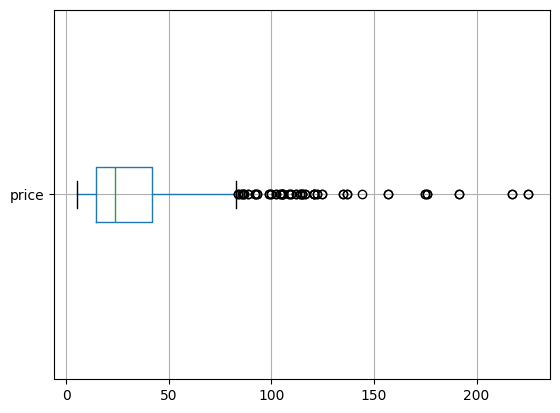

In [87]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge.boxplot(column='price', vert=False)

In [88]:
#Autre méthode avec plotly express
fig = px.box(df_merge, y="price", title="Distribution des prix des produits", width=600, height=400)
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [89]:
#Calculer la moyenne du prix
#Calculer l'écart-type du prix

moyenne = df_merge['price'].mean()
ecart_type = df_merge['price'].std()
z_score = (df_merge['price']- moyenne) / ecart_type
print(f"La moeyenne du prix est : {moyenne:.2f}, l'écart-type : {ecart_type:.2f}.")

La moeyenne du prix est : 32.34, l'écart-type : 27.07.


In [90]:
#Calculer le Z-score
df_merge['z_score'] = (df_merge['price']- moyenne) / ecart_type

In [91]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
df_merge[['price', 'z_score']][df_merge['z_score'] > 3].sort_values(by='z_score', ascending=True).head(5)

,price,z_score
1255,114.0,3.016456
1254,114.0,3.016456
1359,115.0,3.053397
1360,115.0,3.053397
1366,115.0,3.053397


In [92]:
seuil = 3 * ecart_type + moyenne
print(f"le seuil pour un z-score à 3 est : {seuil:.2f}.")

le seuil pour un z-score à 3 est : 113.55.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [93]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion


In [94]:
#Définir un seuil pour les articles "outliers" en prix


In [95]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"


In [96]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [97]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article

#Calculer la somme de la colonne "ca_par_article"
#Ce résultat correspond au chiffre d'affaire du site web


In [98]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge

#Réinitialiser l'index du dataset par un reset_index

#Afficher les 20 premiers articles en CA

#Graphique en barre des 20 premiers articles avec plotly express


In [99]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [100]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge

#Réinitialiser l'index du dataset par un reset_index

#Afficher les 20 premiers articles en quantité

#Graphique en barre des 20 premiers articles avec plotly express


In [101]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [102]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 

#Création de la colonne Rotation de stock

#Remplacement des "inf" par 0

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock

In [103]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros

#Calculer la somme de la colonne "Valorisation_stock_euros"

In [104]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [105]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT

#Création de la colonne Taux de marge

#Afficher le prix minimum de la colonne "taux_marge"

#Afficher le prix maximum de la colonne "taux_marge"


In [106]:
#Affichage de la ligne avec un taux de marge inférieur à 0


In [107]:
#Création d'un dataframe avec les taux positifs

#Afficher le prix minimum de la colonne "taux_marge"

#Afficher le prix maximum de la colonne "taux_marge"


In [108]:
#Création d'un dataframe avec le taux de marge moyen par type de produit

#Affichage dans un graphique du taux de marge par type de produit


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

In [109]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn

#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap

In [110]:
#Que peut-on conclure des corrélations ?

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [111]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
